In [ ]:
import pandas as pd
import numpy as np

# 1. Preprocesiranje master tabele

U prethodnom notebook-u izvrsena je analiza pocetnih tabela i formirana je master tabela `master_raw.csv`, u kojoj je svaki red predstavljen jednim oglasom za posao.  
U ovom notebook-u nastavlja se rad nad tom tabelom, sa ciljem pripreme podataka za klasterovanje.

Prvi korak preprocesiranja predstavlja uklanjanje atributa koji nisu pogodni za klasterovanje. To ukljucuje kolone sa velikim procentom nedostajucih vrednosti, identifikatore, URL adrese, tekstualne opise, tehnicke atribute, kao i atribute vezane za platu, koji nece biti korisceni kao ulazne karakteristike za klasterovanje.

In [2]:
master = pd.read_csv("../data/master_raw.csv")

/tmp/ipykernel_61384/1961299549.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv("../data/master_raw.csv")


In [3]:
missing_percent = (master.isna().mean() * 100).sort_values(ascending=False)

missing_percent[missing_percent > 0]

closed_time                   99.133622
skills_desc                   98.030666
med_salary                    94.929309
remote_allowed                87.689848
applies                       81.170619
max_salary                    75.944093
min_salary                    75.944093
normalized_salary             70.873402
currency                      70.873402
compensation_type             70.873402
pay_period                    70.873402
posting_domain                32.271556
application_url               29.604599
formatted_experience_level    23.745852
fips                          22.135827
zip_code                      16.852780
company_size                   5.415466
company_name                   1.387981
country                        1.387173
follower_count                 1.387173
employee_count                 1.387173
company_id                     1.386366
views                          1.363757
description                    0.005652
dtype: float64

### Obrada tekstualnih atributa

Tekstualni atributi zahtevaju posebnu obradu i predstavljaju znacajan izvor informacija o samim poslovima. Medjutim, nisu svi tekstualni atributi podjednako korisni za klasterovanje.

Kolone `company_name`, `skills_desc` i `description` uklonjene su iz trenutne verzije skupa podataka. Naziv kompanije ne opisuje karakteristike posla, dok `skills_desc` i `description` sadrze velike kolicine slobodnog teksta koje bi zahtevale dodatne NLP tehnike i znacajno povecale slozenost analize.

Sa druge strane, kolona `title` zadrzana je u skupu podataka jer sadrzi sazet i informativan opis radne pozicije. Ovaj atribut moze imati znacajnu ulogu u razlikovanju tipova poslova i bice posebno obradjen u kasnijim fazama preprocesiranja.

In [4]:
high_missing_cols = missing_percent[missing_percent > 81].index.tolist()
salary_cols = ["max_salary", "med_salary", "min_salary", "pay_period",
               "currency", "compensation_type", "normalized_salary"]

id_cols = ["job_id", "company_id"]
url_cols = ["job_posting_url", "application_url", "posting_domain"]

text_cols = ["description", "skills_desc", "company_name"]

time_cols = ["original_listed_time", "listed_time", "expiry", "closed_time"]

technical_cols = ["zip_code", "fips", "sponsored"]

In [5]:
cols_to_drop = list(set(high_missing_cols + salary_cols + id_cols + 
                        url_cols + text_cols + time_cols + technical_cols))

cols_to_drop = [col for col in cols_to_drop if col in master.columns]

len(cols_to_drop), cols_to_drop

(24,
 ['applies',
  'remote_allowed',
  'job_id',
  'closed_time',
  'min_salary',
  'description',
  'fips',
  'job_posting_url',
  'listed_time',
  'company_name',
  'posting_domain',
  'application_url',
  'skills_desc',
  'normalized_salary',
  'max_salary',
  'compensation_type',
  'company_id',
  'original_listed_time',
  'expiry',
  'currency',
  'zip_code',
  'sponsored',
  'med_salary',
  'pay_period'])

In [6]:
master_clean = master.drop(columns=cols_to_drop)

In [7]:
master_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Columns: 133 entries, title to Wholesale Building Materials
dtypes: float64(126), object(7)
memory usage: 125.7+ MB


# 2. Analiza preostalih atributa i uklanjanje nedostajucih vrednosti

Nakon uklanjanja nerelevantnih kolona, u tabeli je ostalo 123849 redova i 133 kolone. U ovom koraku analiziraju se preostali atributi kako bi se odredilo koje kolone su numericke, koje su kategoricske, koliko jos uvek ima nedostajucih vrednosti i koje dodatne transformacije su potrebne pre primene algoritama klasterovanja.

In [1]:
numeric_cols = master_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = master_clean.select_dtypes(include=["object", "bool"]).columns.tolist()

print(len(numeric_cols))
print(len(categorical_cols))

NameError: name 'master_clean' is not defined

In [9]:
categorical_cols

['title',
 'location',
 'formatted_work_type',
 'application_type',
 'formatted_experience_level',
 'work_type',
 'country']

### Obrada nedostajucih vrednosti kategorijskih atributa

Analizom kategorijskih atributa utvrdjeno je da pojedine kolone imaju veoma veliki broj jedinstvenih vrednosti. Kolona `title` sadrzi preko 70000 razlicitih naziva pozicija i zadrzana je za kasniju tekstualnu obradu. Kolona `location` sadrzi vise od 8000 razlicitih lokacija i uklonjena je kako bi se izbeglo znacajno povecanje dimenzionalnosti skupa podataka.

Kolona `application_type` zadrzana je jer sadrzi mali broj kategorija pogodnih za kodiranje. Za atribut `formatted_experience_level` nedostajuce vrednosti zamenjene su kategorijom `Unknown`, kako bi se ocuvala informacija o nedostajucim podacima.

In [10]:
master_clean["formatted_work_type"].value_counts(dropna=False)

formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

In [11]:
master_clean["work_type"].value_counts(dropna=False)

work_type
FULL_TIME     98814
CONTRACT      12117
PART_TIME      9696
TEMPORARY      1190
INTERNSHIP      983
VOLUNTEER       562
OTHER           487
Name: count, dtype: int64

### Redundantni atributi

Analizom atributa `formatted_work_type` i `work_type` utvrdjeno je da obe kolone sadrze istu informaciju zapisanu u razlicitom formatu. Prikazom raspodele vrednosti i medjusobnim poredjenjem kategorija ustanovljeno je potpuno preslikavanje izmedju ova dva atributa.

Kako bi se izbegla redundantnost podataka i nepotrebno povecanje dimenzionalnosti skupa, kolona `work_type` uklonjena je iz dalje analize, dok je zadrzana citljivija kolona `formatted_work_type`.

In [12]:
master_clean = master_clean.drop(columns=["work_type"])

In [13]:
print(master_clean["title"].nunique(),"\n")
print(master_clean["location"].nunique(), "\n")
print(master_clean["application_type"].value_counts(dropna=False), "\n")
print(master_clean["formatted_experience_level"].value_counts(dropna=False),"\n")
print(master_clean["country"].nunique(), "\n")


72521 

8526 

application_type
OffsiteApply          84607
ComplexOnsiteApply    31049
SimpleOnsiteApply      8192
UnknownApply              1
Name: count, dtype: int64 

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64 

81 



In [14]:
master_clean["formatted_experience_level"] = (master_clean["formatted_experience_level"].fillna("Unknown"))

master_clean = master_clean.drop(columns=["location"])

In [15]:
master_clean.isna().sum().sort_values(ascending=False).head(20)

company_size                  6707
country                       1718
follower_count                1718
employee_count                1718
views                         1689
formatted_work_type              0
title                            0
application_type                 0
formatted_experience_level       0
ACCT                             0
ADM                              0
ADVR                             0
ANLS                             0
ART                              0
BD                               0
CNSL                             0
CUST                             0
DIST                             0
DSGN                             0
EDU                              0
dtype: int64

### Analiza atributa country

Atribut `country` sadrzi informacije o drzavi u kojoj se posao nalazi. Tokom analize uocena je pojava vrednosti `0`, koja ne predstavlja validnu drzavu i tretirana je kao nedostajuci podatak.

Nakon uklanjanja ove anomalije i zamene nedostajucih vrednosti kategorijom `Unknown`, atribut je zadrzan u skupu podataka jer predstavlja jedinu geografsku informaciju koja je ostala nakon uklanjanja detaljnijih lokacijskih podataka.

In [16]:
master_clean["country"].value_counts(dropna=False)

country
US     109995
GB       3000
0        2632
NaN      1718
CA       1399
        ...  
LB          1
MC          1
HN          1
VE          1
AF          1
Name: count, Length: 82, dtype: int64

In [17]:
(master_clean["country"] == "0").sum()

np.int64(2632)

In [18]:
master_clean.loc[master_clean["country"] == "0",["country"]].head()

,country
32,0
78,0
102,0
114,0
148,0


In [20]:
master_clean["country"] = (master_clean["country"].replace("0", np.nan).fillna("Unknown"))

In [21]:
master_clean["country"].value_counts(dropna=False)

country
US         109995
Unknown      4350
GB           3000
CA           1399
IN            792
            ...  
LB              1
MC              1
HN              1
VE              1
AF              1
Name: count, Length: 81, dtype: int64

### Analiza atributa company_size

Analizom atributa `company_size` i njegovog odnosa sa atributom `employee_count` uoceno je da vise vrednosti atributa `company_size` odgovaraju kompanijama sa vecim brojem zaposlenih. Rast medijane broja zaposlenih kroz kategorije pokazuje da atribut poseduje prirodan redosled.

Zbog toga je `company_size` tretiran kao ordinalni atribut i zadrzan je u numerickom obliku. Na taj nacin izbegava se nepotrebno povecanje dimenzionalnosti koje bi nastalo primenom One-Hot Encoding tehnike.

In [22]:
master_clean["company_size"].value_counts(dropna=False)

company_size
7.0    42779
5.0    22453
2.0    13389
6.0    11146
3.0     9358
1.0     9123
4.0     8894
NaN     6707
Name: count, dtype: int64

In [23]:
master_clean.groupby("company_size")["employee_count"].describe()

,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
1.0,9123.0,117.525704,1061.338386,0.0,14.0,28.0,65.0,29207.0
2.0,13389.0,149.074091,273.991430,0.0,54.0,87.0,158.0,14861.0
3.0,9358.0,421.001817,701.074240,0.0,147.0,281.0,459.0,22333.0
4.0,8894.0,852.874635,2640.065726,0.0,313.0,556.0,917.0,206082.0
5.0,22453.0,2212.252928,3181.533329,0.0,685.0,1388.0,2388.0,63379.0
6.0,11146.0,5026.701776,4238.922321,0.0,2382.0,4303.0,6166.0,35486.0
7.0,42779.0,46994.989621,92889.049534,0.0,8984.0,19253.0,42695.0,748312.0


Nedostajuce vrednosti atributa `company_size` popunjene su medijanom. Ovaj atribut predstavlja ordinalnu promenljivu koja opisuje velicinu kompanije kroz unapred definisane kategorije. Koriscenje medijane omogucava ocuvanje prirodnog redosleda kategorija bez uvodjenja dodatnih vestackih vrednosti.

In [24]:
master_clean["company_size"] = (master_clean["company_size"].fillna(master_clean["company_size"].median())
                                )

In [25]:
master_clean["company_size"] = master_clean["company_size"].astype(int)

In [26]:
master_clean.isna().sum().sort_values(ascending=False).head(20)

follower_count                1718
employee_count                1718
views                         1689
formatted_work_type              0
title                            0
application_type                 0
formatted_experience_level       0
country                          0
company_size                     0
ACCT                             0
ADM                              0
ADVR                             0
ANLS                             0
ART                              0
BD                               0
CNSL                             0
CUST                             0
DIST                             0
DSGN                             0
EDU                              0
dtype: int64

### Obrada nedostajucih vrednosti numerickih atributa

Preostale nedostajuce vrednosti odnosile su se na atribute `follower_count`, `employee_count` i `views`. S obzirom da ovi atributi predstavljaju numericke promenljive sa potencijalno izrazenim ekstremnim vrednostima, za imputaciju je koriscena medijana odgovarajuce kolone.

Koriscenje medijane predstavlja robusniji pristup u odnosu na aritmeticku sredinu, jer je manje osetljivo na prisustvo veoma velikih ili veoma malih vrednosti. Nakon ovog koraka skup podataka vise ne sadrzi nedostajuce vrednosti.

In [27]:
master_clean["follower_count"] = (master_clean["follower_count"].fillna(master_clean["follower_count"].median()))

master_clean["employee_count"] = (master_clean["employee_count"].fillna(master_clean["employee_count"].median()))

master_clean["views"] = (master_clean["views"].fillna(master_clean["views"].median()))

In [28]:
master_clean.isna().sum().sort_values(ascending=False).head(10)

title                         0
views                         0
formatted_work_type           0
application_type              0
formatted_experience_level    0
company_size                  0
country                       0
employee_count                0
follower_count                0
ACCT                          0
dtype: int64

In [29]:
master_clean.shape

(123849, 131)

In [30]:
master_clean.to_csv("../data/master_clean.csv", index=False)

# 3. Transformacija kategorickih atributa

Algoritmi klasterovanja zahtevaju numericke ulazne podatke, zbog cega je potrebno transformisati preostale kategoricke atribute u odgovarajuci numericki oblik.

Kao sto je vec receno u prethodnom postupku, preostale kategoricke atribute cemo transformisati pomocu One-Hot kodiranja, a atribut `title` cemo zbog velike kolicine podataka izdvojiti za posebnu obradu.

In [31]:
categorical_for_ohe = [
    "formatted_work_type",
    "application_type",
    "formatted_experience_level",
    "country"
]

In [32]:
master_clean[categorical_for_ohe].nunique()

formatted_work_type            7
application_type               4
formatted_experience_level     7
country                       81
dtype: int64

In [33]:
master_ohe = pd.get_dummies(
    master_clean,
    columns=categorical_for_ohe,
    drop_first=False,
    dtype=int
)

In [34]:
master_ohe.shape[1]

226

In [35]:
master_clean["title"] = (master_clean["title"].str.lower().str.strip())

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf = TfidfVectorizer(stop_words="english", max_features=300, min_df=10,
                        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")

title_tfidf = tfidf.fit_transform(master_clean["title"])

In [38]:
title_tfidf.shape

(123849, 300)

In [39]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['access' 'account' 'accountant' 'accounting' 'accounts' 'administrative'
 'administrator' 'advisor' 'agent' 'ai' 'aide' 'analyst' 'analytics'
 'application' 'architect' 'area' 'assistant' 'associate' 'assurance'
 'attendant' 'attorney' 'auditor' 'auto' 'automation' 'automotive'
 'banker' 'behavior' 'benefits' 'bilingual' 'bonus' 'branch' 'business'
 'ca' 'care' 'case' 'cashier' 'cdl' 'center' 'certified' 'chain' 'chief'
 'city' 'civil' 'claims' 'clearance' 'clerk' 'client' 'clinic' 'clinical'
 'cloud']


In [40]:
master_clean["title"].value_counts().head(30)

title
sales manager                      673
customer service representative    482
project manager                    360
assistant store manager            320
administrative assistant           261
senior accountant                  244
salesperson                        241
executive assistant                232
registered nurse                   216
receptionist                       205
staff accountant                   204
account executive                  196
retail sales associate             190
sales associate                    190
store manager                      186
software engineer                  182
controller                         178
account manager                    173
senior software engineer           162
assistant manager                  161
maintenance technician             159
business development manager       154
business analyst                   150
general manager                    138
data analyst                       137
outside sales repre

In [41]:
from sklearn.decomposition import TruncatedSVD

In [42]:
explained = []

for n in [50, 100, 150, 200, 250, 300]:
    svd = TruncatedSVD(n_components=n, random_state=42)
    svd.fit(title_tfidf)
    explained.append(
        (n, svd.explained_variance_ratio_.sum())
    )

explained

[(50, np.float64(0.49849631655561705)),
 (100, np.float64(0.685205211324029)),
 (150, np.float64(0.8007027552517751)),
 (200, np.float64(0.8863917122109454)),
 (250, np.float64(0.9573068969055283)),
 (300, np.float64(1.0000000000000016))]

Za redukciju dimenzionalnosti TF-IDF reprezentacije atributa `title` primenjena je metoda TruncatedSVD. Analizirana je kolicina objasnjene varijanse za razlicit broj komponenti. Kao kompromis izmedju ocuvanja informacija i smanjenja dimenzionalnosti odabrano je 200 komponenti, cime je zadrzano priblizno 88.6% ukupne varijanse.

In [43]:
svd = TruncatedSVD(n_components=200, random_state=42)
title_svd = svd.fit_transform(title_tfidf)

In [44]:
title_svd_df = pd.DataFrame(title_svd, columns=[f"title_svd_{i+1}" for i in range(title_svd.shape[1])],
                            index = master_ohe.index)

In [45]:
master_transformed = pd.concat([
    master_ohe.drop(columns=["title"]),
    title_svd_df
],
axis = 1)



In [46]:
master_transformed.shape

(123849, 425)

Primenom TruncatedSVD metode TF-IDF reprezentacija atributa `title` smanjena je sa 300 na 200 komponenti. Na ovaj nacin zadrzano je priblizno 88.6% varijanse, uz smanjenje dimenzionalnosti tekstualnog dela skupa podataka.

Nakon spajanja ovih komponenti sa ostatkom transformisanih atributa dobijena je tabela `master_transformed`, koja sadrzi iskljucivo numericke atribute i predstavlja osnovu za naredne korake preprocesiranja. Pomenutih atributa ima 425.


# 4. Skaliranje atributa

Posto algoritmi klasterovanja zavise od rastojanja izmedju tacaka, atributi moraju biti svedeni na uporedivu skalu. Bez skaliranja, atributi sa velikim vrednostima, kao sto su `employee_count`, `follower_count` i `views`, mogli bi da dominiraju nad binarnim i TF-IDF/SVD atributima.

In [47]:
master_clean[
    [
        "views",
        "employee_count",
        "follower_count",
        "company_size"
    ]
].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
views,123849.0,14.473439,8.532471e+01,1.0,1.0,2.0,3.0,4.0,7.0,47.0,175.0,9975.0
employee_count,123849.0,17234.244411,5.876765e+04,0.0,2.0,12.0,197.0,1686.0,10889.0,76436.6,245662.0,748312.0
follower_count,123849.0,496700.909454,2.281623e+06,0.0,44.0,668.0,12350.0,53344.0,207884.0,1907472.0,8913602.0,32702835.0
company_size,123849.0,4.938918,1.998390e+00,1.0,1.0,1.0,3.0,5.0,7.0,7.0,7.0,7.0


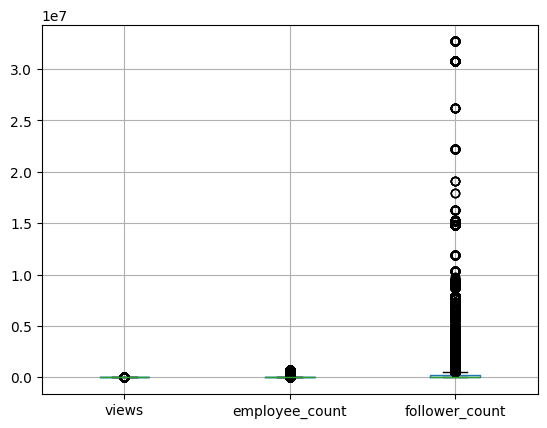

In [48]:
import matplotlib.pyplot as plt

master_clean[
    ["views", "employee_count", "follower_count"]
].boxplot()

plt.show()

## Transformacija atributa sa izrazito asimetricnim raspodelama

Analiza atributa `views`, `employee_count` i `follower_count` pokazala je postojanje izrazito asimetricnih raspodela sa dugackim desnim repom. Veliki broj oglasa i kompanija poseduje relativno male vrednosti ovih atributa, dok manji broj kompanija ima izuzetno veliki broj pregleda, zaposlenih ili pratilaca.

Iako ove vrednosti predstavljaju stvarne karakteristike kompanija i ne smatraju se greskama u podacima, njihovo prisustvo moze znacajno uticati na algoritme zasnovane na rastojanjima, kao i na metode redukcije dimenzionalnosti.

Zbog toga je nad atributima `views`, `employee_count` i `follower_count` primenjena logaritamska transformacija koriscenjem funkcije `log1p(x) = log(1 + x)`. Ova transformacija smanjuje uticaj ekstremno velikih vrednosti, pri cemu se zadrzava informacija o relativnim razlikama izmedju kompanija i oglasa.

In [49]:
master_transformed["views"] = np.log1p(master_transformed["views"])
master_transformed["employee_count"] = np.log1p(master_transformed["employee_count"])
master_transformed["follower_count"] = np.log1p(master_transformed["follower_count"])

In [50]:
master_transformed[
    [
        "views",
        "employee_count",
        "follower_count"
    ]
].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
views,123849.0,1.935064,0.898239,0.693147,0.693147,1.098612,1.386294,1.609438,2.079442,3.871201,5.170484,9.207937
employee_count,123849.0,7.225372,2.679547,0.000000,1.098612,2.564949,5.288267,7.430707,9.295600,11.244226,12.411716,13.525577
follower_count,123849.0,10.713768,2.407709,0.000000,3.806662,6.505784,9.421492,10.884536,12.244740,14.461290,16.003089,17.302972


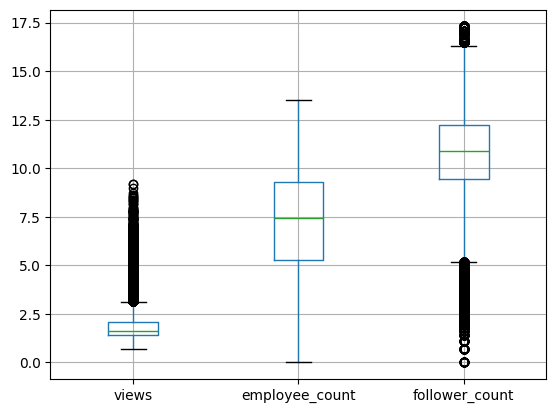

In [51]:
import matplotlib.pyplot as plt

master_transformed[
    [
        "views",
        "employee_count",
        "follower_count"
    ]
].boxplot()

plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

df_for_clustering = master_transformed.copy()

numeric_cols = [
    "views",
    "employee_count",
    "follower_count",
    "company_size"
]

title_cols = [col for col in df_for_clustering.columns if col.startswith("title_svd_")]

ohe_cols = [
    col for col in df_for_clustering.columns
    if col not in numeric_cols + title_cols
]

scaler_numeric = StandardScaler()
scaler_title = StandardScaler()

X_numeric_scaled = scaler_numeric.fit_transform(df_for_clustering[numeric_cols]).astype(np.float32)
X_title_scaled = scaler_title.fit_transform(df_for_clustering[title_cols]).astype(np.float32)
X_ohe = df_for_clustering[ohe_cols].astype(np.float32).values

X_scaled = np.hstack([
    X_numeric_scaled,
    X_ohe,
    X_title_scaled
]).astype(np.float32)

X_scaled.shape

(123849, 425)

In [54]:
final_columns = numeric_cols + ohe_cols + title_cols

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=final_columns,
    index=master_transformed.index
)

X_scaled_df.head()

,views,employee_count,follower_count,company_size,ACCT,ADM,ADVR,ANLS,ART,BD,...,title_svd_191,title_svd_192,title_svd_193,title_svd_194,title_svd_195,title_svd_196,title_svd_197,title_svd_198,title_svd_199,title_svd_200
0,1.235153,-0.457704,-1.225546,-1.470648,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.027279,-0.091802,0.058213,0.060757,-0.188647,0.267843,-0.280849,-0.093031,-0.009417,0.060966
1,-1.382618,0.076631,0.070926,0.030566,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.618782,4.225534,-1.515599,4.181480,2.871402,0.225678,1.970047,-0.881347,-1.270002,-0.130059
2,0.291861,-1.661774,-2.907421,-1.971053,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.548634,0.525473,0.666387,-0.414988,-0.890227,0.006499,-0.254972,-0.502744,0.734187,-0.522396
3,0.999904,-0.678550,-1.212338,-1.470648,0.0,0.0,0.0,0.0,0.0,0.0,...,0.153298,-0.002809,0.142502,-0.401065,-0.024706,0.167608,0.045500,0.073834,0.292861,-0.511220
4,-0.610942,0.076631,0.070926,0.030566,0.0,0.0,0.0,0.0,0.0,0.0,...,0.150416,-0.317052,0.094242,0.058535,-0.013355,-0.052864,0.160645,-0.030921,-0.227304,-0.228254


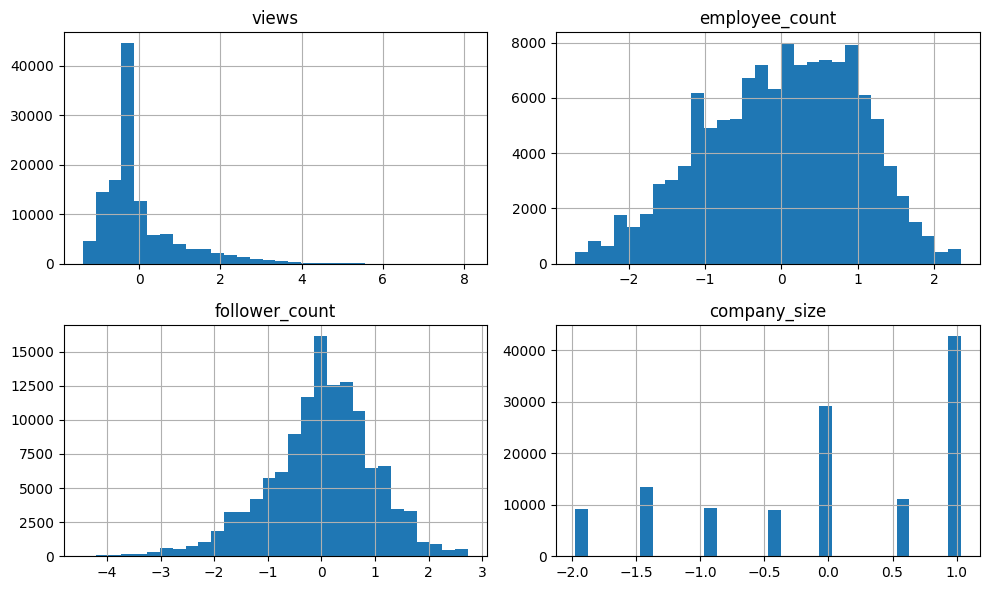

In [55]:
X_scaled_df[["views","employee_count","follower_count","company_size"]].hist(figsize=(10, 6),bins=30)
plt.tight_layout()
plt.show()

# 5. Redukcija dimenzionalnosti primenom PCA
Nakon transformacije i standardizacije atributa, skup podataka i dalje sadrzi veliki broj dimenzija. Kako bi se smanjila slozenost podataka i uklonile redundantne informacije, primenjuje se analiza glavnih komponenti (PCA).

Cilj PCA metode je pronalazenje manjeg broja novih atributa koji zadrzavaju sto veci deo informacije sadrzane u originalnom skupu podataka.

In [56]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled_df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [57]:

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

In [58]:
cumulative_variance[:20]

array([0.01289767, 0.02039875, 0.02689938, 0.03250709, 0.03803559,
       0.04341966, 0.04869702, 0.0537973 , 0.05886622, 0.06390887,
       0.0689346 , 0.07391435, 0.07886958, 0.08381366, 0.08875314,
       0.09367331, 0.09858884, 0.10348205, 0.10836492, 0.11323928],
      dtype=float32)

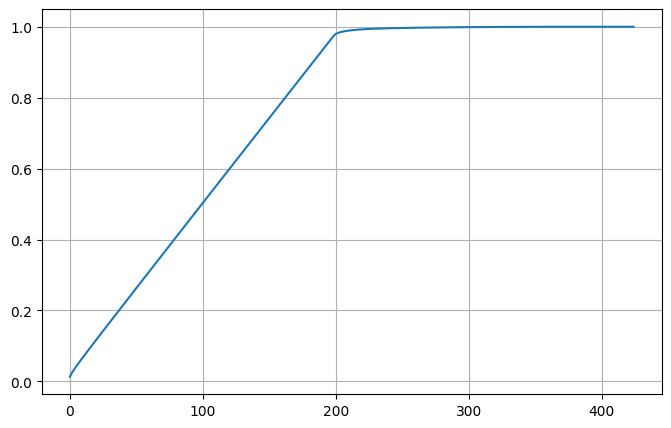

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.grid(True)
plt.show()

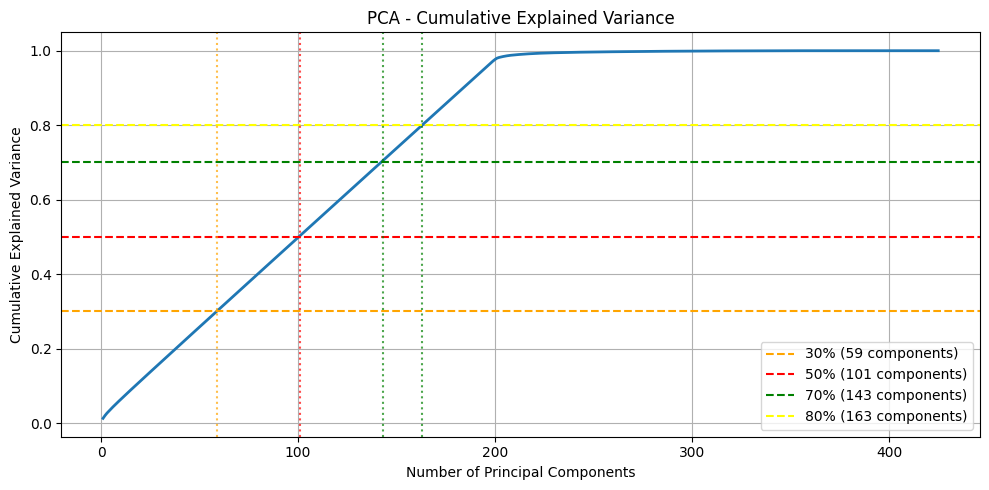

In [60]:
import numpy as np
import matplotlib.pyplot as plt

n30 = np.argmax(cumulative_variance >= 0.30) + 1
n50 = np.argmax(cumulative_variance >= 0.50) + 1
n70 = np.argmax(cumulative_variance >= 0.70) + 1
n80 = np.argmax(cumulative_variance >= 0.80) + 1

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    linewidth=2
)

ax.axhline(
    y=0.30,
    color="orange",
    linestyle="--",
    label=f"30% ({n30} components)"
)

ax.axhline(
    y=0.50,
    color="red",
    linestyle="--",
    label=f"50% ({n50} components)"
)

ax.axhline(
    y=0.70,
    color="green",
    linestyle="--",
    label=f"70% ({n70} components)"
)

ax.axhline(
    y=0.80,
    color="yellow",
    linestyle="--",
    label=f"80% ({n80} components)"
)

ax.axvline(
    x=n30,
    color="orange",
    linestyle=":",
    alpha=0.7
)

ax.axvline(
    x=n50,
    color="red",
    linestyle=":",
    alpha=0.7
)

ax.axvline(
    x=n70,
    color="green",
    linestyle=":",
    alpha=0.7
)

ax.axvline(
    x=n80,
    color="green",
    linestyle=":",
    alpha=0.7
)

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA - Cumulative Explained Variance")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [61]:
n30 = np.argmax(cumulative_variance >= 0.30) + 1
n50 = np.argmax(cumulative_variance >= 0.50) + 1
n70 = np.argmax(cumulative_variance >= 0.70) + 1
n80 = np.argmax(cumulative_variance >= 0.80) + 1

print(n30, n50, n70, n80)

59 101 143 163


In [62]:
X_scaled_df.shape

(123849, 425)


Analizom kumulativne objasnjene varijanse utvrdjeno je da je za ocuvanje priblizno 70% ukupne varijanse potrebno 232 komponente, dok je za ocuvanje priblizno 80% ukupne varijanse potrebno 288 komponenti.

Kako bi se ispitao uticaj redukcije dimenzionalnosti na kvalitet klasterovanja, zadrzane su tri verzije skupa podataka:

- originalni standardizovani skup sa 425 atributa,
- PCA skup sa 59 komponenti(30% objasnjene varijanse),
- PCA skup sa 101 komponentom (50% objasnjene varijanse),
- PCA skup sa 232 komponente (70% objasnjene varijanse),
- PCA skup sa 288 komponenti (80% objasnjene varijanse).

Algoritmi klasterovanja bice primenjeni nad svih pet verzija skupa podataka, a rezultati ce biti uporedjeni pomocu odgovarajucih metrika kvaliteta klasterovanja.

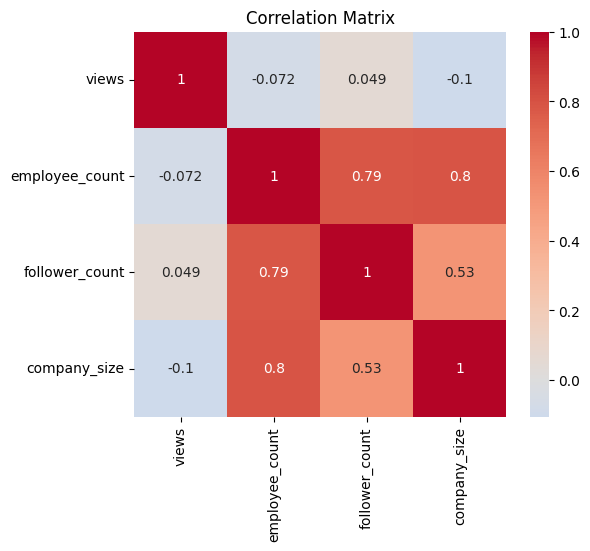

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "views",
    "employee_count",
    "follower_count",
    "company_size"
]

corr = master_transformed[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

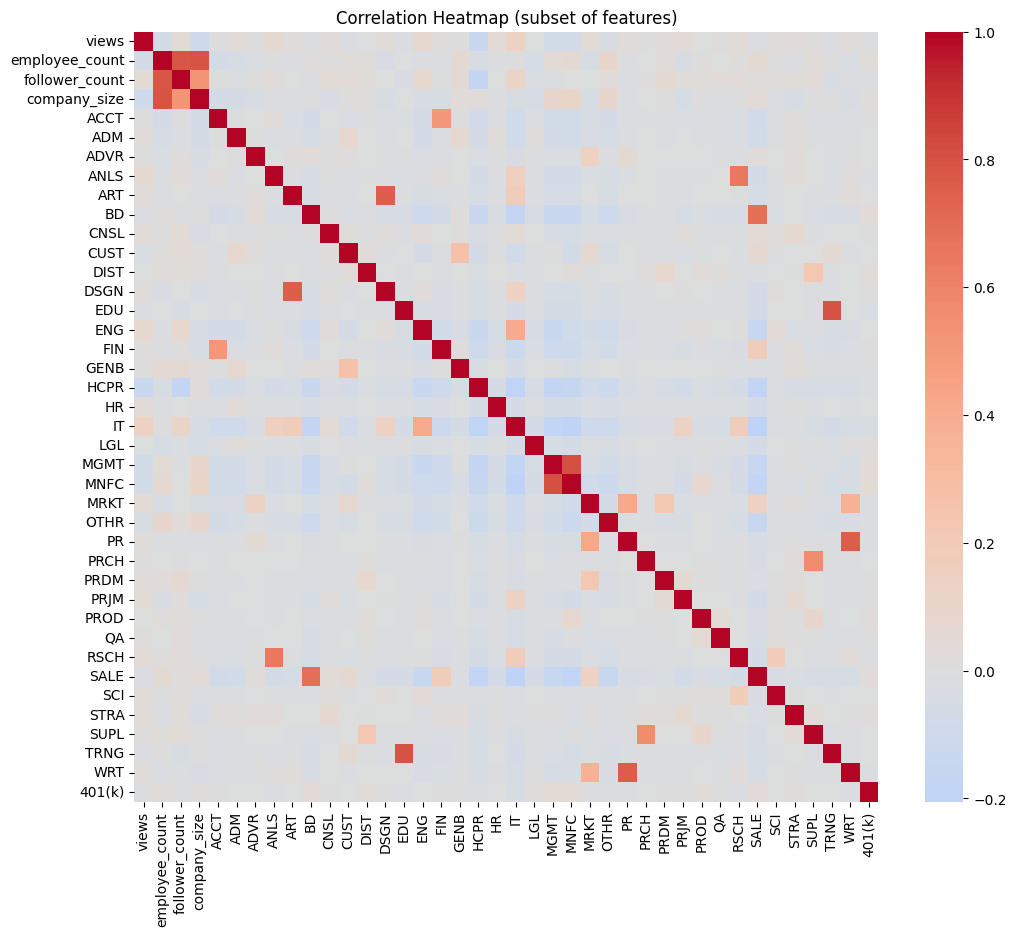

In [64]:
corr = X_scaled_df.iloc[:, :40].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (subset of features)")
plt.show()

In [65]:
pca_30 = PCA(n_components=0.30, random_state=42)
X_pca_30 = pca_30.fit_transform(X_scaled)

pca_50 = PCA(n_components=0.50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)

pca_70 = PCA(n_components=0.70, random_state=42)
X_pca_70 = pca_70.fit_transform(X_scaled)

pca_80 = PCA(n_components=0.80, random_state=42)
X_pca_80 = pca_80.fit_transform(X_scaled)

print(X_scaled.shape)
print(X_pca_30.shape)
print(X_pca_50.shape)
print(X_pca_70.shape)
print(X_pca_80.shape)

(123849, 425)
(123849, 59)
(123849, 101)
(123849, 143)
(123849, 163)


# 6. Cuvanje pripremljenih skupova

Nakon zavrsenog preprocesiranja i redukcije dimenzionalnosti, pripremljeni skupovi podataka sacuvani su za potrebe narednih faza projekta.

Pored kompletnog skaliranog skupa atributa, sacuvane su i PCA reprezentacije sa razlicitim brojem komponenti. Na ovaj nacin izbegava se ponovno izvrsavanje racunski zahtevnih koraka poput TF-IDF transformacije, SVD redukcije tekstualnih atributa, logaritamskih transformacija, skaliranja i PCA analize pri svakom pokretanju eksperimenata.

S obzirom da skup sadrzi vise od 120.000 instanci i veliki broj atributa, ponovno generisanje svih transformacija zahtevalo bi znacajno vreme i dodatnu potrosnju memorije. Cuvanjem pripremljenih skupova omoguceno je efikasnije testiranje i poredjenje razlicitih algoritama klasterovanja.

Posebno su sacuvane PCA reprezentacije koje zadrzavaju 30%, 50%, 70% i 80% ukupne varijanse. Na taj nacin moguce je brzo izvrsavati klasterovanje nad razlicitim nivoima redukcije dimenzionalnosti bez potrebe za ponovnim racunanjem PCA transformacije.

In [68]:
import gc

del X_numeric_scaled
del X_title_scaled
del X_ohe

gc.collect()

43783

In [69]:
X_scaled.shape

(123849, 425)

In [70]:
X_scaled_df.memory_usage(deep=True).sum() / 1024**3

np.float64(0.19608384743332863)

In [71]:
X_scaled_df.to_csv("../data/data_full_scaled.csv")

In [73]:
import gc

pd.DataFrame(X_pca_30).to_csv(
    "../data/X_pca_30.csv",
    index=False
)

del X_pca_30
gc.collect()

1830

In [74]:
import gc

pd.DataFrame(X_pca_50).to_csv(
    "../data/X_pca_50.csv",
    index=False
)

del X_pca_50
gc.collect()

0

In [75]:
import gc

pd.DataFrame(X_pca_70).to_csv(
    "../data/X_pca_70.csv",
    index=False
)

del X_pca_70
gc.collect()

0

In [ ]:
import gc

pd.DataFrame(X_pca_80).to_csv(
    "../data/X_pca_80.csv",
    index=False
)

del X_pca_80
gc.collect()

0

: 